# Laboratorio 06 - Lab02: Regresión Lineal Múltiple con PyTorch
## Predicción de Precios de Viviendas
**Estudiante:** Karen Villarpando Olmedo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
ruta = 'kc_house_data.csv'
df = pd.read_csv(ruta)

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente
Filas: 21613
Columnas: 21


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Preparación de los datos

# Eliminar datos nulos
df_modelo = df.dropna().copy()

# Quitar columnas que no utilizaremos para entrenar
df_modelo = df_modelo.drop(['id', 'date'], axis=1)

# Convertir zipcode en variables numéricas
df_modelo = pd.get_dummies(
    df_modelo,
    columns=['zipcode'],
    drop_first=True,
    dtype=float
)

# Variable objetivo
y = df_modelo['price'].values.astype(np.float32)

# Variables predictoras
columnas_x = [col for col in df_modelo.columns if col != 'price']
X = df_modelo[columnas_x].values.astype(np.float32)

print("Total de datos:", X.shape[0])
print("Variables predictoras:", X.shape[1])
print("Variable objetivo: price")

Total de datos: 21613
Variables predictoras: 86
Variable objetivo: price


# 4. División y normalización

In [4]:
# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# Mezclar los índices
torch.manual_seed(42)
indices = torch.randperm(len(X_tensor))

# 80% entrenamiento / 20% prueba
n_train = int(0.8 * len(X_tensor))

idx_train = indices[:n_train]
idx_test = indices[n_train:]

X_train = X_tensor[idx_train]
X_test = X_tensor[idx_test]

y_train = y_tensor[idx_train]
y_test = y_tensor[idx_test]

# Normalizar usando solamente los datos de entrenamiento
media = X_train.mean(dim=0)
desv = X_train.std(dim=0)

# Evitar división entre cero
desv[desv == 0] = 1

X_train = (X_train - media) / desv
X_test = (X_test - media) / desv

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: torch.Size([17290, 86]) torch.Size([17290, 1])
Prueba: torch.Size([4323, 86]) torch.Size([4323, 1])


# 5. Dataset y DataLoader

In [5]:
# Dataset y DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Datos de entrenamiento:", len(train_dataset))
print("Datos de prueba:", len(test_dataset))
print("Lotes de entrenamiento:", len(train_loader))
print("Lotes de prueba:", len(test_loader))

Datos de entrenamiento: 17290
Datos de prueba: 4323
Lotes de entrenamiento: 271
Lotes de prueba: 68


# 6. Modelo de Regresión Múltiple con PyTorch

In [6]:
# Modelo de Regresión Lineal Múltiple

class RegresionMultiple(nn.Module):

    def __init__(self, n_entradas):
        super().__init__()
        self.linear = nn.Linear(n_entradas, 1)

    def forward(self, x):
        return self.linear(x)


modelo = RegresionMultiple(X_train.shape[1])

print(modelo)

RegresionMultiple(
  (linear): Linear(in_features=86, out_features=1, bias=True)
)


# 7. Función de costo y optimizador

In [7]:
# Función de costo y optimizador

criterio = nn.MSELoss()

optimizador = torch.optim.Adam(
    modelo.parameters(),
    lr=0.01
)

print("Función de costo:", criterio)
print("Optimizador:", optimizador.__class__.__name__)

Función de costo: MSELoss()
Optimizador: Adam


# 8. Entrenamiento del modelo

In [9]:
# Guardamos los precios reales para usarlos después
y_train_real = y_train.clone()
y_test_real = y_test.clone()

# Media y desviación SOLO del entrenamiento
media_y = y_train.mean()
desv_y = y_train.std()

# Normalizar precio
y_train = (y_train - media_y) / desv_y
y_test = (y_test - media_y) / desv_y

print("Media del precio:", media_y.item())
print("Desviación del precio:", desv_y.item())

Media del precio: 539682.25
Desviación del precio: 370207.34375


In [10]:
# Recrear Dataset y DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# Reiniciar modelo
modelo = RegresionMultiple(X_train.shape[1])

# Reiniciar función de costo y optimizador
criterio = nn.MSELoss()

optimizador = torch.optim.Adam(
    modelo.parameters(),
    lr=0.01
)

print("Modelo reiniciado correctamente")

Modelo reiniciado correctamente


In [11]:
# Entrenamiento del modelo

epochs = 100
historial_loss = []

for epoch in range(epochs):

    modelo.train()
    loss_total = 0

    for X_batch, y_batch in train_loader:

        # Predicción
        y_pred = modelo(X_batch)

        # Calcular error
        loss = criterio(y_pred, y_batch)

        # Backpropagation
        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        loss_total += loss.item()

    loss_promedio = loss_total / len(train_loader)
    historial_loss.append(loss_promedio)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss_promedio:.2f}")

Epoch 10: Loss = 0.22
Epoch 20: Loss = 0.22
Epoch 30: Loss = 0.22
Epoch 40: Loss = 0.23
Epoch 50: Loss = 0.22
Epoch 60: Loss = 0.22
Epoch 70: Loss = 0.23
Epoch 80: Loss = 0.22
Epoch 90: Loss = 0.22
Epoch 100: Loss = 0.22


# 9. Gráfica de pérdida

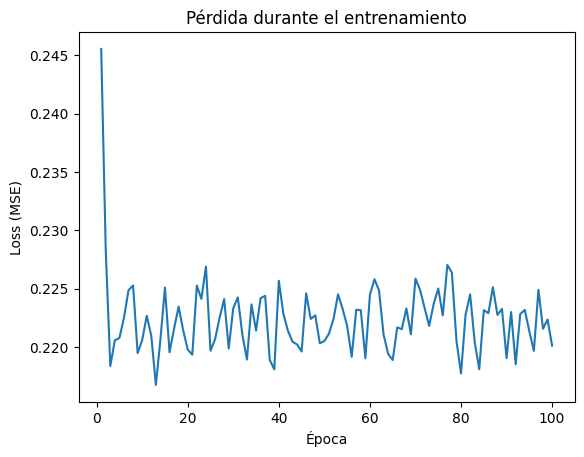

In [12]:
# Gráfica del entrenamiento

plt.plot(range(1, epochs + 1), historial_loss)

plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.title("Pérdida durante el entrenamiento")

plt.show()

# 10. Evaluación del modelo

In [13]:
# Evaluación del modelo

modelo.eval()

with torch.no_grad():

    # Predicción en escala normalizada
    y_pred_norm = modelo(X_test)

    # Volver a precios reales
    y_pred_test = y_pred_norm * desv_y + media_y

    # Valores reales
    y_test_real = y_test * desv_y + media_y

    # Métricas
    mse = torch.mean((y_pred_test - y_test_real) ** 2)
    rmse = torch.sqrt(mse)
    mae = torch.mean(torch.abs(y_pred_test - y_test_real))

print(f"MSE: {mse.item():.2f}")
print(f"RMSE: {rmse.item():.2f}")
print(f"MAE: {mae.item():.2f}")

MSE: 28692848640.00
RMSE: 169389.64
MAE: 111796.27


# 11. Inferencia con una casa inventada

In [14]:
# Inferencia con una casa inventada

# Partimos del promedio de las características
casa_nueva = X.mean(axis=0).copy()

# Modificamos algunas características
casa_nueva[columnas_x.index('bedrooms')] = 3
casa_nueva[columnas_x.index('bathrooms')] = 2
casa_nueva[columnas_x.index('sqft_living')] = 2000
casa_nueva[columnas_x.index('sqft_lot')] = 6000
casa_nueva[columnas_x.index('floors')] = 2
casa_nueva[columnas_x.index('waterfront')] = 0
casa_nueva[columnas_x.index('view')] = 0
casa_nueva[columnas_x.index('condition')] = 3
casa_nueva[columnas_x.index('grade')] = 7

# Convertir a tensor
casa_tensor = torch.tensor(casa_nueva, dtype=torch.float32)

# Normalizar igual que los datos de entrenamiento
casa_tensor = (casa_tensor - media) / desv

# Predicción
modelo.eval()

with torch.no_grad():
    pred_norm = modelo(casa_tensor.unsqueeze(0))

    # Regresar el precio a su escala real
    prediccion = pred_norm * desv_y + media_y

print(f"Precio estimado de la vivienda: ${prediccion.item():,.2f}")

Precio estimado de la vivienda: $444,952.19


# 12. Comparación: valores reales vs predichos

In [15]:
# Comparación de valores reales y predichos

modelo.eval()

with torch.no_grad():

    pred_norm = modelo(X_test)

    # Volver a escala real
    predicciones = pred_norm * desv_y + media_y
    reales = y_test * desv_y + media_y


print(f"{'Real':>15} {'Predicción':>15}")
print("-" * 32)

for i in range(10):

    real = reales[i].item()
    pred = predicciones[i].item()

    print(f"{real:15.2f} {pred:15.2f}")

           Real      Predicción
--------------------------------
      450000.00       505364.19
      219500.00        83851.06
      226550.00       176761.81
      602000.00       554675.00
      874000.00       845906.88
      745000.00       688685.19
      660500.00       784861.25
      330000.00       404814.78
     2400000.00      1857327.38
      407193.00       362776.19


# 13. Gráfica de valores reales vs predichos

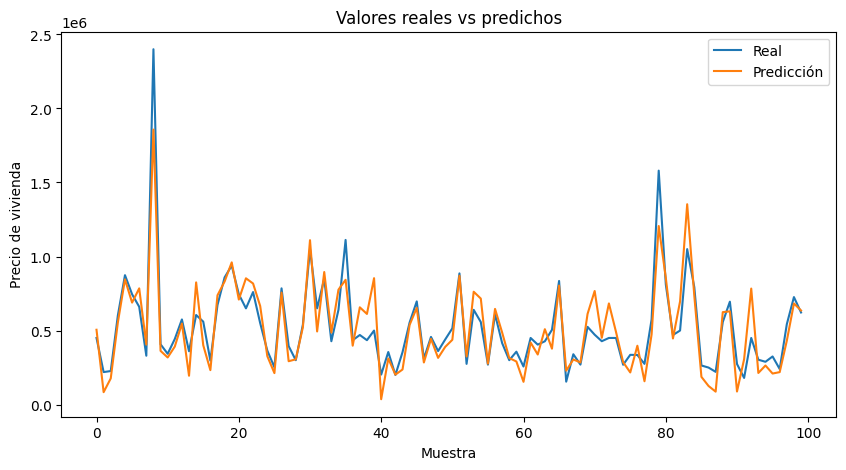

In [16]:
# Comparación gráfica

reales_graf = reales[:100].numpy().flatten()
predichos_graf = predicciones[:100].numpy().flatten()

plt.figure(figsize=(10, 5))

plt.plot(reales_graf, label='Real')
plt.plot(predichos_graf, label='Predicción')

plt.xlabel('Muestra')
plt.ylabel('Precio de vivienda')
plt.title('Valores reales vs predichos')
plt.legend()

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

# 14. Guardar los pesos del modelo


In [18]:

ruta_modelo = '/content/gdrive/MyDrive/modelo_lab02_karen_pytorch.pth'

torch.save(modelo.state_dict(), ruta_modelo)

print("Modelo guardado correctamente")
print("Ruta:", ruta_modelo)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Modelo guardado correctamente
Ruta: /content/gdrive/MyDrive/modelo_lab02_karen_pytorch.pth
